# 가치 반복법(Value Iteration) 구현: 3x4 그리드 월드 예제

### GridWorld 시각화를 위한 설정

In [1]:
import os
import urllib.request

if not os.path.exists("gridworld_render.py"):
    url = "https://raw.githubusercontent.com/agtechresearch/MLapplications-graduate/main/common/gridworld_render.py"
    filename = "gridworld_render.py"
    urllib.request.urlretrieve(url, filename)

In [2]:
import numpy as np
import gridworld_render as render_helper
from collections import defaultdict  # defaultdict 클래스 임포트

### GridWorld 클래스의 정의

In [3]:
class GridWorld:
    def __init__(self):
        self.action_space = [0, 1, 2, 3]  # 행동 공간(가능한 행동들)
        self.action_meaning = {  # 행동의 의미
            0: "UP",
            1: "DOWN",
            2: "LEFT",
            3: "RIGHT",
        }

        self.reward_map = np.array(  # 보상 맵(각 좌표의 보상 값)
            [[0, 0, 0, 1.0],
             [0, None, 0, -1.0],
             [0, 0, 0, 0]]
        )
        self.goal_state = (0, 3)    # 목표 상태(좌표)
        self.wall_state = (1, 1)    # 벽 상태(좌표)
        self.start_state = (2, 0)   # 시작 상태(좌표)
        self.agent_state = self.start_state   # 에이전트 초기 상태(좌표)

    @property
    def height(self):
        return len(self.reward_map)

    @property
    def width(self):
        return len(self.reward_map[0])

    @property
    def shape(self):
        return self.reward_map.shape

    def actions(self):
        return self.action_space

    def states(self):
        for h in range(self.height):
            for w in range(self.width):
                yield (h, w)

    def next_state(self, state, action):
        # 이동 위치 계산
        action_move_map = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        move = action_move_map[action]
        next_state = (state[0] + move[0], state[1] + move[1])
        ny, nx = next_state

        # 이동한 위치가 그리드 월드의 테두리 밖이나 벽인가?
        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height:
            next_state = state
        elif next_state == self.wall_state:
            next_state = state

        return next_state  # 다음 상태 반환

    def reward(self, state, action, next_state):
        return self.reward_map[next_state]

    def reset(self):
        self.agent_state = self.start_state
        return self.agent_state

    def step(self, action):
        state = self.agent_state
        next_state = self.next_state(state, action)
        reward = self.reward(state, action, next_state)
        done = (next_state == self.goal_state)

        self.agent_state = next_state
        return next_state, reward, done

    def render_v(self, v=None, policy=None, print_value=True):
        renderer = render_helper.Renderer(self.reward_map, self.goal_state,
                                          self.wall_state)
        renderer.render_v(v, policy, print_value)

    def render_q(self, q=None, print_value=True):
        renderer = render_helper.Renderer(self.reward_map, self.goal_state,
                                          self.wall_state)
        renderer.render_q(q, print_value)


### argmax() 함수의 구현: 딕셔너리를 매개변수로 받아 값이 가장 큰 원소의 키를 반환

In [4]:
def argmax(d):
    """d (dict)"""
    max_value = max(d.values())
    max_key = -1
    for key, value in d.items():
        if value == max_value:
            max_key = key
    return max_key

### greedy_policy() 함수의 구현: 가치 함수 V, 환경 env, 감쇠인자 gamma 를 매개변수로 받고, 탐욕화한 정책(Greedy Policy)를 반환

In [5]:
def greedy_policy(V, env, gamma):
    pi = {}

    for state in env.states():
        action_values = {}

        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values[action] = value

        max_action = argmax(action_values)
        action_probs = {0: 0, 1: 0, 2: 0, 3: 0}
        action_probs[max_action] = 1.0
        pi[state] = action_probs
    return pi

### 아래 수식에 따라 한 번만 갱신하는 value_iter_onestep() 함수를 구현

<img src="https://raw.githubusercontent.com/agtechresearch/MLapplications-graduate/main/image/Bellman_optimality.png">

In [6]:
def value_iter_onestep(V, env, gamma):
    for state in env.states():       # 모든 상태에 차례로 접근
        if state == env.goal_state:  # 목표 상태에서의 가치 함수는 항상 0
            V[state] = 0
            continue

        action_values = []
        for action in env.actions():  # 모든 행동에 차례로 접근
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]  # 새로운 가치 함수
            action_values.append(value)

        V[state] = max(action_values)  # 최댓값 추출
    return V

In [7]:
def value_iter(V, env, gamma, threshold=0.001, is_render=True):
    while True:
        if is_render:
            env.render_v(V)

        old_V = V.copy()  # 갱신 전 가치 함수
        V = value_iter_onestep(V, env, gamma)

        # 갱신된 양의 최댓값 구하기
        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        # 임계값과 비교
        if delta < threshold:
            break
    return V

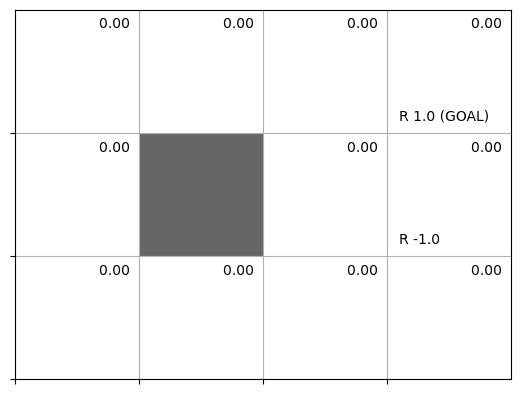

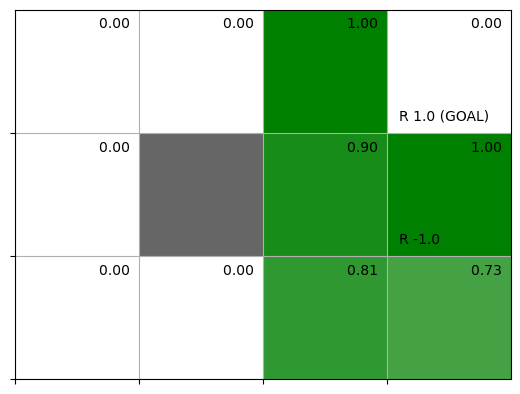

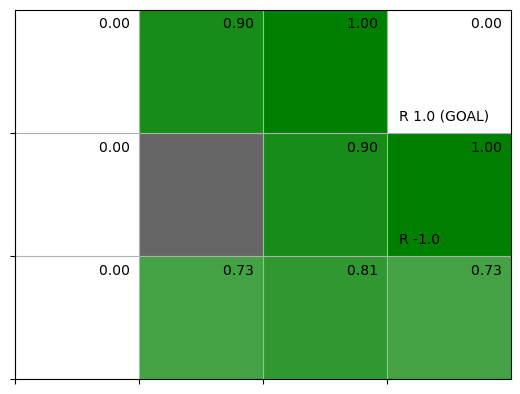

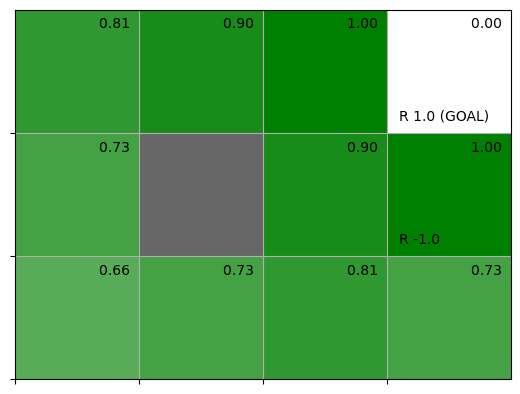

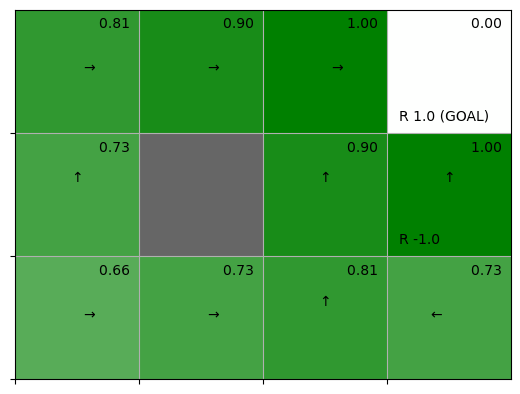

In [8]:
V = defaultdict(lambda: 0)
env = GridWorld()
gamma = 0.9

V = value_iter(V, env, gamma)  # 최적 가치 함수 찾기

pi = greedy_policy(V, env, gamma)  # 최적 정책 찾기
env.render_v(V, pi)